<a href="https://colab.research.google.com/github/Sowmixh/AML-assignment/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving SuperMarket Analysis.csv to SuperMarket Analysis.csv
Accuracy: 0.33
Precision: 0.3132888198757764
Recall: 0.33
F1 Score: 0.3130292397660818


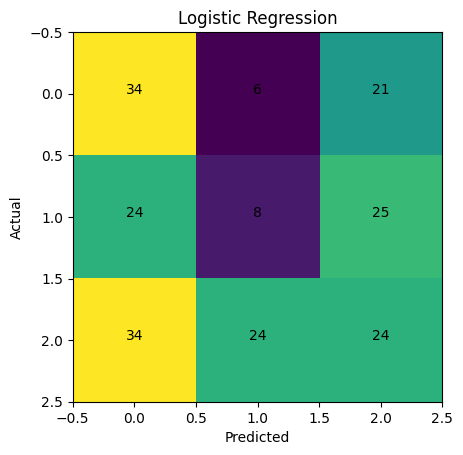

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("SuperMarket Analysis.csv")

# Drop useless columns
df = df.drop(columns=['Invoice ID', 'Date', 'Time'])

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop(columns=['Payment'])   # Target = Payment
y = df['Payment']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center')

plt.show()